# Pipeline Hydraulics: Full Workflow

This notebook walks through a complete steady-state hydraulic analysis on
a representative crude oil pipeline:

1. Build a multi-segment pipeline with realistic geometry and pump stations
2. Compute the hydraulic profile along the route
3. Visualize the hydraulic gradient diagram (the canonical pipeline chart)
4. Compare light crude vs heavy crude on the same route to show viscosity effects
5. Sensitivity analysis: how does throughput affect pumping power?
6. Gas pipeline comparison: Weymouth vs Panhandle B equations

The example pipeline approximates a 500-mile Cushing-to-Houston route
typical of light-crude pipelines in the US Gulf Coast region. Topology
is realistic; the precise routing is illustrative rather than a copy of
any specific operating pipeline.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline_hydraulics.io.examples import cushing_to_houston_example, heavy_crude_pipeline
from pipeline_hydraulics.network.profile import compute_profile
from pipeline_hydraulics.network.pipeline import Pipeline, PipeSegment, PumpStation
from pipeline_hydraulics.fluids.properties import WTI_CRUDE, WCS_HEAVY, GASOLINE, DIESEL
from pipeline_hydraulics.viz.gradient import plot_hydraulic_gradient, plot_pump_power_breakdown
from pipeline_hydraulics.hydraulics.gas_flow import weymouth_flow, panhandle_b_flow

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Build the pipeline

The Cushing-to-Houston example is a 500-mile, 30-inch crude pipeline with
two intermediate pump stations (Paris TX and Lufkin TX). The route is
predominantly downhill — Cushing sits at ~270 m elevation, Houston at sea
level — which works in the pipeline's favor for crude movement.

In [2]:
pipeline = cushing_to_houston_example()
print(pipeline.summary())

Pipeline: Cushing-to-Houston Example (Light Crude)
Fluid: West Texas Intermediate (39.6° API) (ρ=827 kg/m³, μ=4.5 cP)
Total length: 500.0 mi (805 km)
Total elevation change: -260 m
Inlet pressure: 1,233 psi
Segments: 5
Pump stations: 2


In [3]:
# Show the segment-by-segment breakdown
segment_df = pd.DataFrame([
    {
        "Segment": seg.name,
        "Length (mi)": seg.length_mi,
        "Diameter (in)": seg.diameter_in,
        "Inlet elev (m)": seg.inlet_elevation_m,
        "Outlet elev (m)": seg.outlet_elevation_m,
        "Δ elev (m)": seg.elevation_change_m,
        "MAOP (psi)": seg.maop_pa / 6894.76,
    }
    for seg in pipeline.segments
])
segment_df

,Segment,Length (mi),Diameter (in),Inlet elev (m),Outlet elev (m),Δ elev (m),MAOP (psi)
0,Cushing to Paris TX,150.00,30.00,270,170,-100,"1,440.22"
1,Paris to Longview,110.00,30.00,170,110,-60,"1,440.22"
2,Longview to Lufkin,90.00,30.00,110,80,-30,"1,440.22"
3,Lufkin to Conroe,90.00,30.00,80,40,-40,"1,440.22"
4,Conroe to Houston Terminal,60.00,30.00,40,10,-30,"1,440.22"


## 2. Hydraulic profile at design throughput

At a target throughput of 270,000 barrels per day (0.5 m³/s), the pipeline
walks segment-by-segment computing pressure drop from friction and
elevation change. Each pump station adds head between segments, restoring
pressure for the next leg.

In [4]:
flow_rate = 0.5  # m³/s ≈ 270 kbpd (barrels per day)
flow_kbpd = flow_rate * 86400 / 0.158987 / 1000  # m³/s to kbpd via barrels/day

profile = compute_profile(pipeline, flow_rate_m3_s=flow_rate)

print(f"Flow rate: {flow_rate:.2f} m³/s ({flow_kbpd:.0f} kbpd)")
print(f"Inlet pressure:       {pipeline.inlet_pressure_pa/6894.76:.0f} psi")
print(f"Outlet pressure:      {profile.outlet_pressure_psi:.0f} psi")
print(f"Total pump power:     {profile.total_pump_power_kw:,.0f} kW")
print(f"MAOP violations:      {len(profile.maop_violations)}")
print(f"Suction violations:   {len(profile.suction_violations)}")
print(f"Operation feasible:   {profile.is_feasible}")

Flow rate: 0.50 m³/s (272 kbpd)
Inlet pressure:       1233 psi
Outlet pressure:      1137 psi
Total pump power:     3,906 kW
MAOP violations:      0
Suction violations:   0
Operation feasible:   True


## 3. Hydraulic gradient diagram

This is the canonical pipeline engineering chart — pressure profile on
top, terrain elevation on bottom. It immediately reveals operating margins
and pump station effectiveness.

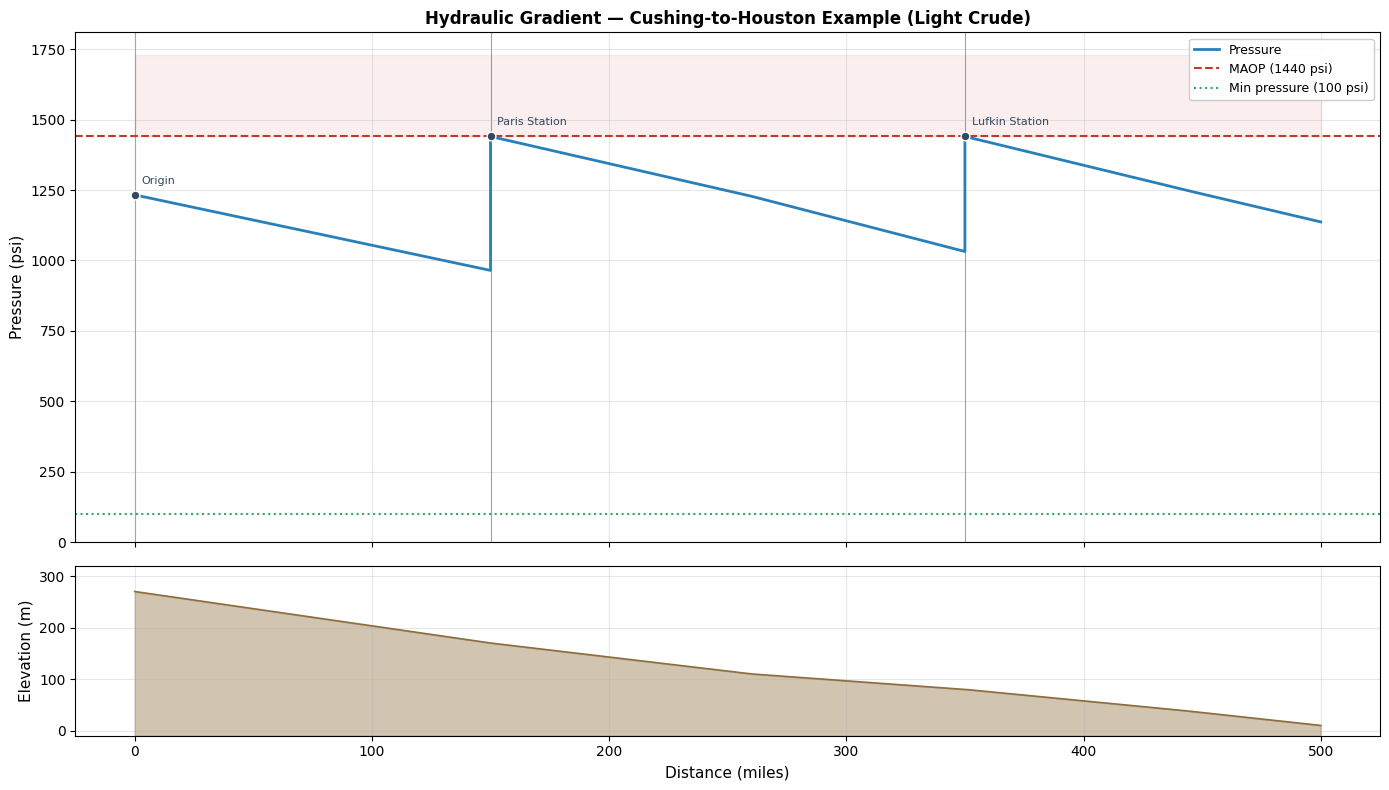

In [5]:
fig = plot_hydraulic_gradient(
    profile, pipeline,
    min_delivery_pressure_psi=100,
)
plt.show()

**Reading this chart.**

- The blue line is pressure declining along each segment from friction and
  elevation change, then jumping back up at each pump station (visible at
  Paris ~150 mi and Lufkin ~350 mi).
- The red dashed line at 1440 psi is MAOP. Operators size pump stations to
  push discharge pressure right up to MAOP — this maximizes the useful
  pressure head out of each station. You can see Paris and Lufkin do
  exactly this.
- The green dotted line at 100 psi is the minimum delivery pressure
  contractually required at Houston. The pipeline exits at ~1140 psi,
  well above this — there's substantial operating margin.
- The brown terrain profile underneath shows the steady downhill route.
  This terrain assists the flow (elevation loss recovers as pressure),
  which is why outlet pressure stays high despite ~500 miles of friction
  losses.

## 4. Light crude vs heavy crude

Same route, same geometry, same flow rate — but transport heavy crude
(Western Canadian Select, ~78x more viscous than WTI) instead. The
hydraulic impact is dramatic. Heavy crude pipelines are typically blended
with lighter "diluents" before transport to avoid exactly this problem.

In [6]:
# Heavy crude on the same route
pipeline_heavy = heavy_crude_pipeline()
profile_heavy = compute_profile(pipeline_heavy, flow_rate_m3_s=flow_rate)

comparison = pd.DataFrame({
    "Light Crude (WTI)": [
        WTI_CRUDE.api_gravity,
        WTI_CRUDE.viscosity_pa_s * 1000,
        profile.outlet_pressure_psi,
        profile.total_pump_power_kw,
    ],
    "Heavy Crude (WCS)": [
        WCS_HEAVY.api_gravity,
        WCS_HEAVY.viscosity_pa_s * 1000,
        profile_heavy.outlet_pressure_psi,
        profile_heavy.total_pump_power_kw,
    ],
}, index=["API gravity", "Viscosity (cP)", "Outlet pressure (psi)", "Pump power (kW)"])
comparison["Ratio (Heavy/Light)"] = comparison["Heavy Crude (WCS)"] / comparison["Light Crude (WTI)"]
comparison.style.format("{:.1f}")

,Light Crude (WTI),Heavy Crude (WCS),Ratio (Heavy/Light)
API gravity,39.6,20.5,0.5
Viscosity (cP),4.5,350.0,77.8
Outlet pressure (psi),1136.9,792.3,0.7
Pump power (kW),3906.1,6802.1,1.7


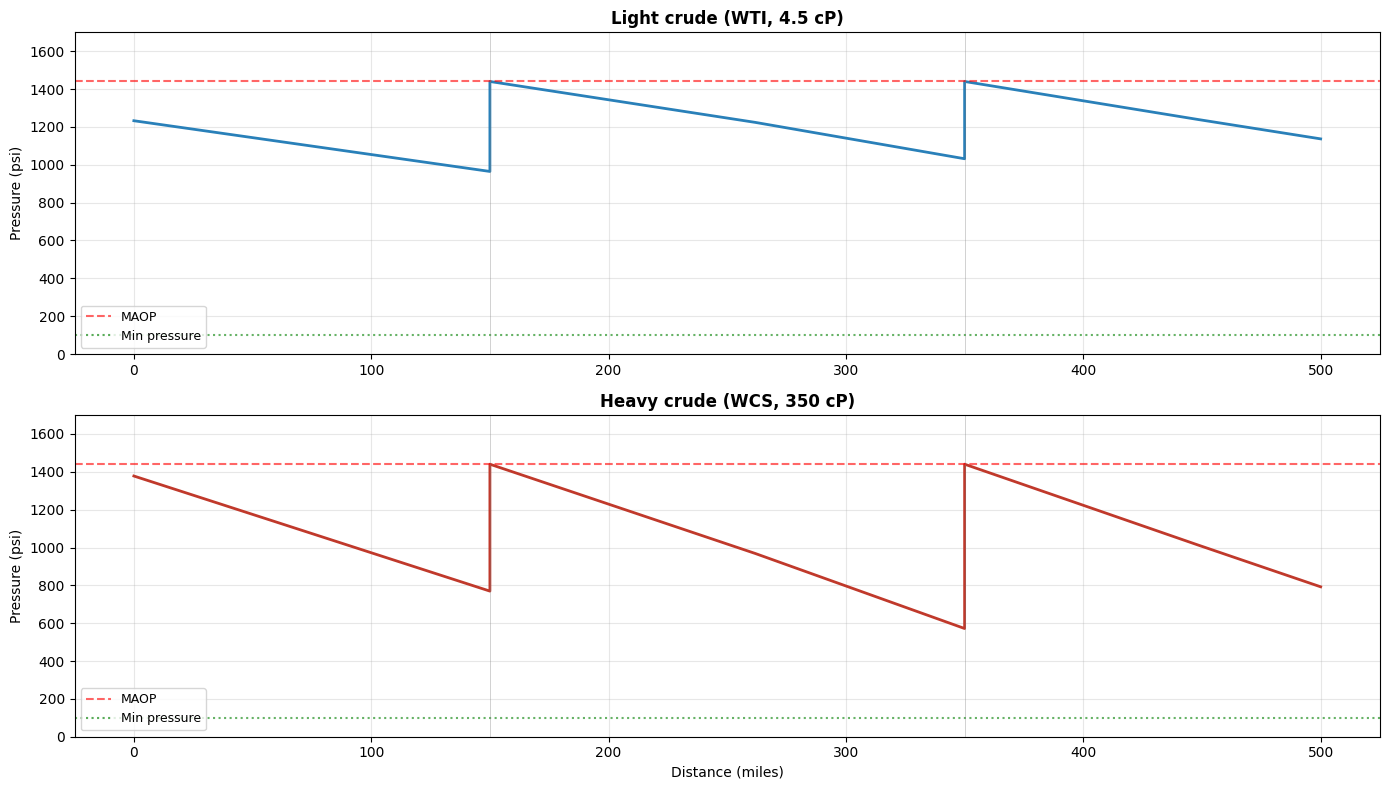

In [7]:
# Side-by-side gradient comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, prof, pipe, title, color in [
    (axes[0], profile, pipeline, "Light crude (WTI, 4.5 cP)", "#2980b9"),
    (axes[1], profile_heavy, pipeline_heavy, "Heavy crude (WCS, 350 cP)", "#c0392b"),
]:
    df = prof.to_dataframe()
    ax.plot(df["distance_mi"], df["pressure_psi"], color=color, lw=2)
    ax.axhline(pipe.segments[0].maop_pa / 6894.76, color="red", ls="--", alpha=0.6, label="MAOP")
    ax.axhline(100, color="green", ls=":", alpha=0.6, label="Min pressure")

    # Mark stations
    stations_df = df[df["is_station"] & df["station"].notna() & (df["station"] != "Origin")]
    for _, st in stations_df.iterrows():
        ax.axvline(st["distance_mi"], color="gray", lw=0.5, alpha=0.5)

    ax.set_ylabel("Pressure (psi)")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1700)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left", fontsize=9)

axes[1].set_xlabel("Distance (miles)")
plt.tight_layout()
plt.show()

**The viscosity effect is huge.** Friction loss scales roughly with
viscosity in laminar flow and weakly (through Reynolds number) in turbulent
flow. WCS is so viscous it pushes flow into the laminar or transitional
regime even at high velocity, dramatically increasing friction losses.

Real heavy-crude pipelines handle this in two ways:
1. **Diluents** (DilBit) — mix bitumen with light condensate to reduce
   viscosity before transport
2. **Heat tracing** — heat the pipeline to reduce viscosity (used for very
   heavy products like asphalt)

Building a transport-grade fluid is often as much chemistry as it is
geometry.

## 5. Throughput sensitivity

Pumping power scales roughly with throughput cubed for turbulent flow
(power ∝ ΔP × Q, and ΔP scales with v² which scales with Q²). This is the
key economic constraint: doubling throughput requires 8x more pumping
power, and pipeline operators trade off pump capex and energy opex
against capacity utilization.

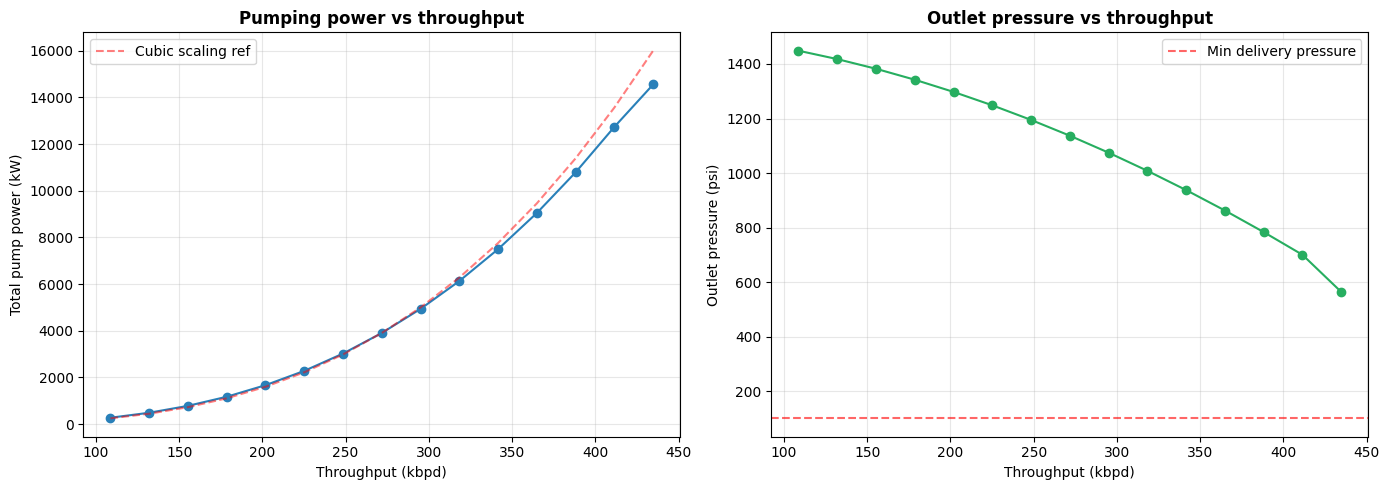

In [8]:
# Sweep throughput from 100 to 400 kbpd
flow_rates = np.linspace(0.2, 0.8, 15)  # m³/s
flow_kbpd_array = flow_rates * 86400 / 0.158987 / 1000  # m³/s to kbpd

powers = []
outlet_pressures = []
for q in flow_rates:
    p = compute_profile(pipeline, flow_rate_m3_s=q)
    powers.append(p.total_pump_power_kw)
    outlet_pressures.append(p.outlet_pressure_psi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(flow_kbpd_array, powers, "o-", color="#2980b9", markersize=6)
ax1.set_xlabel("Throughput (kbpd)")
ax1.set_ylabel("Total pump power (kW)")
ax1.set_title("Pumping power vs throughput", fontweight="bold")
ax1.grid(True, alpha=0.3)

# Overlay cubic scaling reference
q_ref = flow_kbpd_array[len(flow_kbpd_array)//2]
p_ref = powers[len(powers)//2]
ax1.plot(flow_kbpd_array, p_ref * (flow_kbpd_array/q_ref)**3,
         color="red", ls="--", alpha=0.5, label="Cubic scaling ref")
ax1.legend()

ax2.plot(flow_kbpd_array, outlet_pressures, "o-", color="#27ae60", markersize=6)
ax2.axhline(100, color="red", ls="--", alpha=0.6, label="Min delivery pressure")
ax2.set_xlabel("Throughput (kbpd)")
ax2.set_ylabel("Outlet pressure (psi)")
ax2.set_title("Outlet pressure vs throughput", fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**Two observations:**

1. **Power scales superlinearly.** The red dashed reference line is exact
   cubic scaling. Actual power scales a bit less than cubically because
   the friction factor decreases slightly with Reynolds number (smoother
   relative behavior at higher flow). For practical purposes, doubling
   throughput on a fixed-geometry pipeline at least quadruples energy
   consumption.

2. **Outlet pressure declines monotonically with throughput.** Higher flow
   means more friction loss between stations, and stations can only add
   so much head before hitting MAOP. At some throughput, outlet pressure
   drops below the contractual minimum and the pipeline is "full" — to
   move more product you'd need either another pump station, a parallel
   line ("looping"), or a higher-MAOP design.

## 6. Pump station power breakdown

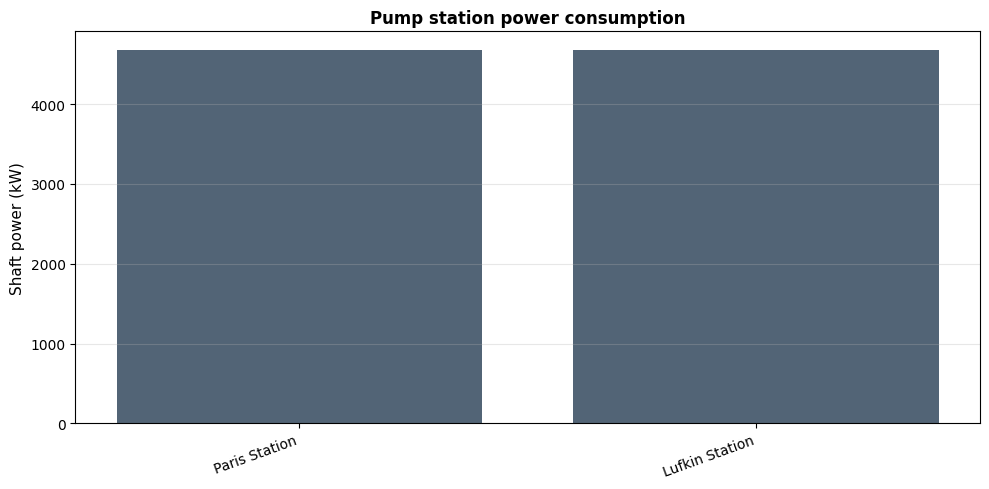


If operating year-round at design throughput:
  Total annual energy: 34,217 MWh
  Annual energy cost (@ $0.08/kWh): $2,737,360


In [9]:
fig = plot_pump_power_breakdown(profile, pipeline)
plt.show()

# Energy at $0.08/kWh for context
hours_per_year = 8760
annual_energy_mwh = profile.total_pump_power_kw * hours_per_year / 1000
annual_cost_usd = annual_energy_mwh * 1000 * 0.08
print(f"\nIf operating year-round at design throughput:")
print(f"  Total annual energy: {annual_energy_mwh:,.0f} MWh")
print(f"  Annual energy cost (@ $0.08/kWh): ${annual_cost_usd:,.0f}")

Energy cost for a single mid-size crude pipeline runs into the
millions per year. This is why pipeline operators care intensely about
pump efficiency and route optimization — even a few percentage points of
efficiency improvement compounds into significant operating savings.

## 7. Gas pipeline equations: Weymouth vs Panhandle B

Gas pipelines use empirical correlations rather than Darcy-Weisbach because
gas density changes substantially with pressure. The two industry-standard
correlations differ in their underlying friction factor assumptions:

- **Weymouth (1912)** — assumes fully-turbulent flow (friction factor
  depends only on diameter, not on Reynolds number). Best for short,
  high-pressure pipelines.
- **Panhandle B (1956)** — assumes partially-turbulent flow with a
  Reynolds-dependent friction factor. Best for long transmission lines.

Let's compare them on a representative case: a 100-mile, 36-inch natural
gas transmission line.

In [10]:
# A typical large-diameter gas transmission scenario
p_inlet = 7e6      # ~1015 psia
p_outlet = 5e6     # ~725 psia
length = 100_000   # 100 km ≈ 62 mi
diameter = 0.9     # 36 inches
g_sg = 0.65        # Typical pipeline gas

wm = weymouth_flow(
    p_inlet_pa=p_inlet, p_outlet_pa=p_outlet,
    length_m=length, diameter_m=diameter,
    specific_gravity=g_sg,
)
pb = panhandle_b_flow(
    p_inlet_pa=p_inlet, p_outlet_pa=p_outlet,
    length_m=length, diameter_m=diameter,
    specific_gravity=g_sg,
)

print(f"Pipeline: {length/1609.344:.0f} mi, {diameter*39.37:.0f}-inch, "
      f"{p_inlet/6894.76:.0f} → {p_outlet/6894.76:.0f} psi")
print()
print(f"Weymouth flow:    {wm.flow_rate_mmscfd:>8.0f} MMSCFD")
print(f"Panhandle B flow: {pb.flow_rate_mmscfd:>8.0f} MMSCFD")
print(f"Ratio: {pb.flow_rate_mmscfd / wm.flow_rate_mmscfd:.2f}x")

Pipeline: 62 mi, 35-inch, 1015 → 725 psi

Weymouth flow:         961 MMSCFD
Panhandle B flow:     1103 MMSCFD
Ratio: 1.15x


Both equations give industrially sensible results — large natural gas
transmission lines move hundreds to over a billion cubic feet per day.
Weymouth and Panhandle B diverge based on the friction model: Weymouth
generally predicts lower flow (because it assumes the friction factor is
higher than partially-turbulent flow really exhibits), while Panhandle B's
flow-dependent friction usually predicts higher capacity.

The "correct" choice depends on the specific pipeline. Modern practice
uses the AGA fully-turbulent equation (Colebrook-White-based) for
high-precision work, with Weymouth/Panhandle as quick-look tools.

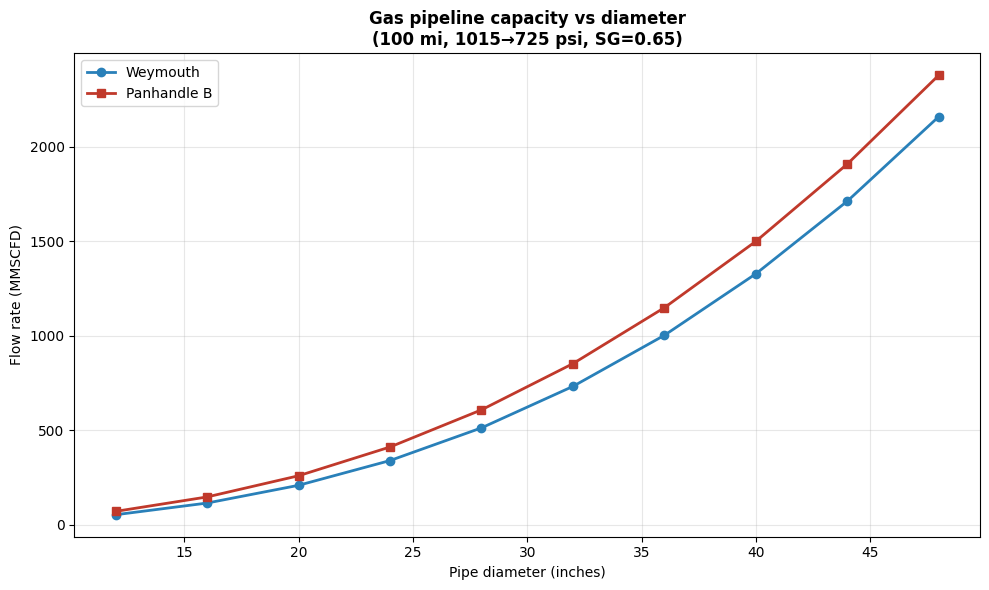

In [11]:
# Diameter sensitivity for both equations
diameters_in = np.arange(12, 49, 4)  # 12" to 48"
diameters_m = diameters_in * 0.0254

wm_flows = []
pb_flows = []
for d in diameters_m:
    wm_d = weymouth_flow(p_inlet, p_outlet, length, d, g_sg)
    pb_d = panhandle_b_flow(p_inlet, p_outlet, length, d, g_sg)
    wm_flows.append(wm_d.flow_rate_mmscfd)
    pb_flows.append(pb_d.flow_rate_mmscfd)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(diameters_in, wm_flows, "o-", color="#2980b9", lw=2, label="Weymouth")
ax.plot(diameters_in, pb_flows, "s-", color="#c0392b", lw=2, label="Panhandle B")
ax.set_xlabel("Pipe diameter (inches)")
ax.set_ylabel("Flow rate (MMSCFD)")
ax.set_title("Gas pipeline capacity vs diameter\n(100 mi, 1015→725 psi, SG=0.65)",
             fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Why such steep scaling with diameter?** Weymouth scales as D^(8/3)
and Panhandle B as D^2.53 — both are very strong functions of pipe size.
Going from a 24" to a 36" line increases capacity by roughly 2.7-2.8x
(not 1.5x, as a linear scaling would suggest). This is why pipeline
operators almost always build the largest economically justifiable
diameter — the unit transportation cost falls off dramatically with size.

## Summary

For the Cushing-to-Houston example pipeline we showed:

| Quantity | Value |
|---|---|
| Pipeline length | 500 miles (805 km) |
| Diameter | 30 inches |
| Pump stations | 2 (Paris, Lufkin) |
| Design throughput | 270 kbpd (light crude) |
| Pumping power | ~3.9 MW |
| Outlet pressure | ~1140 psi |
| Annual energy cost | ~\$2.7M at \$0.08/kWh |

And we observed key effects:
- Heavy crude requires ~1.7x more pumping power than light crude on the
  same route
- Throughput scales superlinearly with pumping power (close to cubic)
- Gas pipeline capacity scales as D^(8/3) — diameter dominates economics

### What's next

- **Pump station placement optimization** — given a route and demand,
  find the optimal number and location of stations
- **Batched product transport** — multiple fluids in sequence (real
  product pipelines move gasoline, diesel, and jet fuel in batches)
- **Compressor station modeling** for gas pipelines
- **Interactive Streamlit dashboard** for what-if analysis

Each is on the project roadmap in the README.